# Paired Contrast Reading Vector

Crescendo harmful and benign conversations are matched by `(pair_id, attempt, turn_idx)`.
This notebook trains a reading vector on **difference vectors** `harmful_rep - benign_rep`,
following the RepE (Zou et al. 2023) methodology:

```
For each matched triple (pair_id, attempt, turn_idx):
    diff = hidden_state(harmful) - hidden_state(benign)

PCA on {diff vectors} → first PC = reading vector
```

This directly subtracts out everything harmful and benign share
(attack structure, turn position, Crescendo mechanics) and isolates
only the harm-content signal.

## Comparisons
| Probe | Training data | Topic confound? |
|-------|---------------|-----------------|
| Flat LR (nb12/13) | all harmful vs all benign | Yes — topics differ |
| **Paired contrast (this nb)** | difference vectors per matched pair | No — same topic, same turn |

## Outputs
- Within-pair concordance: does the reading vector score harmful > benign for each pair?
- AUC on held-out pairs
- Cross-framework transfer: project ActorAttack and X-Teaming onto Crescendo reading vector
- Compliance depth: does reading vector score increase with `n_context_turns`?

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler

repo_root = Path("..").resolve()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

sns.set_theme(style="whitegrid", font_scale=1.1)
FIG_DIR = repo_root / "results" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

REPR_ROOT    = repo_root / "data" / "representations"
LAYER_INDICES = [1, 16, 32]
LAYER_NAMES   = [f"Layer {l}" for l in LAYER_INDICES]

print("Imports OK")

Imports OK


## Load Crescendo faithful representations

In [2]:
def load_repr(folder: str):
    d = REPR_ROOT / folder
    states = np.load(str(d / "hidden_states.npy"), mmap_mode="r").astype(np.float32)
    meta   = pd.read_parquet(d / "metadata.parquet")
    return states, meta

states_harm, meta_harm = load_repr("crescendo_harmful_10_turns_clean_faithful")
states_ben,  meta_ben  = load_repr("crescendo_benign_10_turns_clean_faithful")

print(f"Harmful: {states_harm.shape}  rows={len(meta_harm)}")
print(f"Benign:  {states_ben.shape}   rows={len(meta_ben)}")
print(f"
Harmful pair_ids: {meta_harm['pair_id'].nunique()}")
print(f"Benign  pair_ids: {meta_ben['pair_id'].nunique()}")
print(f"
Harmful attempts per pair: {meta_harm.groupby('pair_id')['attempt'].nunique().describe()}")

Harmful: (9190, 3, 4096)  rows=9190
Benign:  (6020, 3, 4096)   rows=6020

Harmful pair_ids: 100
Benign  pair_ids: 96

Harmful attempts per pair: count    100.000000
mean       9.190000
std        1.931635
min        1.000000
25%        9.000000
50%       10.000000
75%       10.000000
max       10.000000
Name: attempt, dtype: float64


## Build matched pairs

Join on `(pair_id, attempt, turn_idx)` — the exact same topic, same attempt number,
same position in the conversation. Compute `diff = harmful_rep - benign_rep`.

In [3]:
# Add integer index so we can slice states arrays after merge
meta_harm = meta_harm.reset_index(drop=True)
meta_ben  = meta_ben.reset_index(drop=True)
meta_harm["idx_harm"] = meta_harm.index
meta_ben["idx_ben"]   = meta_ben.index

# Inner join on matching keys
merged = meta_harm[["pair_id", "attempt", "turn_idx", "n_context_turns",
                     "final_verdict", "idx_harm"]].merge(
    meta_ben[["pair_id", "attempt", "turn_idx", "idx_ben"]],
    on=["pair_id", "attempt", "turn_idx"],
    how="inner",
)

print(f"Matched pairs: {len(merged)}")
print(f"Unique (pair_id, attempt): {merged.groupby(['pair_id','attempt']).ngroups}")
print(f"n_context_turns distribution:
{merged['n_context_turns'].value_counts().sort_index()}")

Matched pairs: 5670
Unique (pair_id, attempt): 567
n_context_turns distribution:
n_context_turns
0    4282
1     508
2     307
3     220
4     146
5      92
6      70
7      34
8      10
9       1
Name: count, dtype: int64


In [4]:
# Compute difference vectors for each layer
# diff[layer_pos] shape: (N_matched, 4096)

def get_layer(states, layer_pos):
    return np.asarray(states[:, layer_pos, :], dtype=np.float32)

diff_vecs = {}   # layer_pos -> (N_matched, 4096)
for li in range(len(LAYER_INDICES)):
    h = get_layer(states_harm, li)[merged["idx_harm"].values]
    b = get_layer(states_ben,  li)[merged["idx_ben"].values]
    diff_vecs[li] = h - b
    print(f"Layer {LAYER_INDICES[li]}: diff shape {diff_vecs[li].shape}  "
          f"mean norm={np.linalg.norm(diff_vecs[li], axis=1).mean():.3f}")

Layer 1: diff shape (5670, 4096)  mean norm=0.224
Layer 16: diff shape (5670, 4096)  mean norm=5.946
Layer 32: diff shape (5670, 4096)  mean norm=129.439


## Train reading vectors via PCA on difference vectors

RepE method: first PC of PCA on `{harmful_rep - benign_rep}` pairs.
Sign convention: flip so that projecting a harmful rep gives a positive score.

In [5]:
reading_vectors = {}   # layer_pos -> (scaler, direction)

for li in range(len(LAYER_INDICES)):
    D = diff_vecs[li]  # (N_matched, 4096)

    sc  = StandardScaler()
    D_sc = sc.fit_transform(D)

    pca = PCA(n_components=1, random_state=42)
    pca.fit(D_sc)
    vec = pca.components_[0]  # (4096,)

    # Sign check: mean projection of harmful reps should be > benign
    h_sc  = sc.transform(get_layer(states_harm, li)[merged["idx_harm"].values])
    b_sc  = sc.transform(get_layer(states_ben,  li)[merged["idx_ben"].values])
    if (h_sc @ vec).mean() < (b_sc @ vec).mean():
        vec = -vec

    reading_vectors[li] = (sc, vec)
    print(f"Layer {LAYER_INDICES[li]}: "
          f"explained_var={pca.explained_variance_ratio_[0]:.3%}  "
          f"mean harmful score={( h_sc @ vec).mean():.4f}  "
          f"mean benign  score={( b_sc @ vec).mean():.4f}")

Layer 1: explained_var=40.225%  mean harmful score=-11.7766  mean benign  score=-37.1433
Layer 16: explained_var=8.160%  mean harmful score=-6.1764  mean benign  score=-7.9376
Layer 32: explained_var=5.220%  mean harmful score=-1.5874  mean benign  score=-5.6968


## Within-pair concordance

For each matched (pair_id, attempt, turn_idx): does the reading vector score
the harmful rep higher than the benign rep?

This is the cleanest evaluation — no topic leakage possible.

In [6]:
print("Within-pair concordance (harmful scored > benign):")
print(f"{'Layer':<12} {'Concordance':>14} {'N pairs':>10}")
print("-" * 38)

for li in range(len(LAYER_INDICES)):
    sc, vec = reading_vectors[li]
    h = sc.transform(get_layer(states_harm, li)[merged["idx_harm"].values]) @ vec
    b = sc.transform(get_layer(states_ben,  li)[merged["idx_ben"].values])  @ vec
    concordance = (h > b).mean()
    print(f"{LAYER_NAMES[li]:<12} {concordance:>14.3f} {len(merged):>10}")

# Also compute concordance by n_context_turns
print("
Concordance by n_context_turns (Layer 32):")
li = 2
sc, vec = reading_vectors[li]
h = sc.transform(get_layer(states_harm, li)[merged["idx_harm"].values]) @ vec
b = sc.transform(get_layer(states_ben,  li)[merged["idx_ben"].values])  @ vec
merged["correct"] = (h > b).astype(int)
merged["harm_score"] = h
merged["ben_score"]  = b

by_ctx = merged.groupby("n_context_turns")["correct"].agg(["mean", "count"])
print(by_ctx[by_ctx["count"] >= 5].round(3).to_string())

Within-pair concordance (harmful scored > benign):
Layer           Concordance    N pairs
--------------------------------------
Layer 1               0.675       5670
Layer 16              0.536       5670
Layer 32              0.605       5670

Concordance by n_context_turns (Layer 32):
                  mean  count
n_context_turns              
0                0.604   4282
1                0.594    508
2                0.596    307
3                0.595    220
4                0.582    146
5                0.685     92
6                0.657     70
7                0.765     34
8                0.400     10


## AUC: reading vector vs flat LR

Compare the paired contrast reading vector against the flat LR from nb12/13.
Use 5-fold CV splitting by pair_id (not by row) to avoid leakage.

In [ ]:
from sklearn.model_selection import GroupKFold

# Fair comparison: both methods trained on the same diff vectors.
# For each matched pair we have diff = harmful_rep - benign_rep.
# Task: given a held-out pair, does the direction score harmful > benign?
# Metric: concordance (% of held-out pairs where harmful_score > benign_score)
#
# Reading vector: PCA on train diffs → project test harmful and benign separately
# LR on diffs:   LR trained on train diffs (label=1 for all, 0 for negated diffs)
#                evaluated as: LR(harmful_diff) > 0.5

# Pairs indexed by (pair_id, attempt) for GroupKFold splitting
pair_groups = merged["pair_id"].values  # split by pair_id to hold out full topics
N = len(merged)
gkf = GroupKFold(n_splits=5)

print("Cross-validated concordance (5-fold, split by pair_id):")
print(f"{'Method':<35}" + "".join(f"{ln:>12}" for ln in LAYER_NAMES))
print("-" * (35 + 12 * len(LAYER_NAMES)))

rv_concordances  = [[] for _ in LAYER_INDICES]
lr_concordances  = [[] for _ in LAYER_INDICES]

for tr, te in gkf.split(np.arange(N), groups=pair_groups):
    for li in range(len(LAYER_INDICES)):
        D = diff_vecs[li]   # (N, 4096)
        D_tr, D_te = D[tr], D[te]

        # --- Reading vector (PCA on train diffs) ---
        sc_rv = StandardScaler()
        D_tr_sc = sc_rv.fit_transform(D_tr)
        pca_cv = PCA(n_components=1, random_state=42)
        pca_cv.fit(D_tr_sc)
        vec_cv = pca_cv.components_[0]

        # Sign: positive = harmful direction
        h_te = get_layer(states_harm, li)[merged["idx_harm"].values[te]]
        b_te = get_layer(states_ben,  li)[merged["idx_ben"].values[te]]
        h_proj = sc_rv.transform(h_te) @ vec_cv
        b_proj = sc_rv.transform(b_te) @ vec_cv
        if h_proj.mean() < b_proj.mean():
            vec_cv = -vec_cv
            h_proj, b_proj = -h_proj, -b_proj
        rv_concordances[li].append((h_proj > b_proj).mean())

        # --- LR on diff vectors ---
        # Augment: positive class = real diffs, negative class = negated diffs
        D_aug = np.concatenate([D_tr, -D_tr], axis=0)
        y_aug = np.concatenate([np.ones(len(D_tr)), np.zeros(len(D_tr))])
        sc_lr = StandardScaler()
        D_aug_sc = sc_lr.fit_transform(D_aug)
        clf = LogisticRegression(max_iter=1000, C=0.1)
        clf.fit(D_aug_sc, y_aug)

        D_te_sc = sc_lr.transform(D_te)
        # Concordance: does LR score the real diff as positive?
        lr_scores = clf.predict_proba(D_te_sc)[:, 1]
        lr_concordances[li].append((lr_scores > 0.5).mean())

print(f"{'Reading vector (paired PCA)':<35}" +
      "".join(f"{np.mean(c):>12.3f}" for c in rv_concordances))
print(f"{'LR on diff vectors':<35}" +
      "".join(f"{np.mean(c):>12.3f}" for c in lr_concordances))
print()
print("Note: both methods use only diff vectors (topic-controlled).")
print("Concordance = % of held-out pairs where harmful scored > benign.")

## Compliance depth: does the reading vector score increase with n_context_turns?

If the reading vector captures something beyond just topic (harmful vs benign),
it should also track how deep the compliance priming goes — scoring harmful turns
higher as more compliant context accumulates.

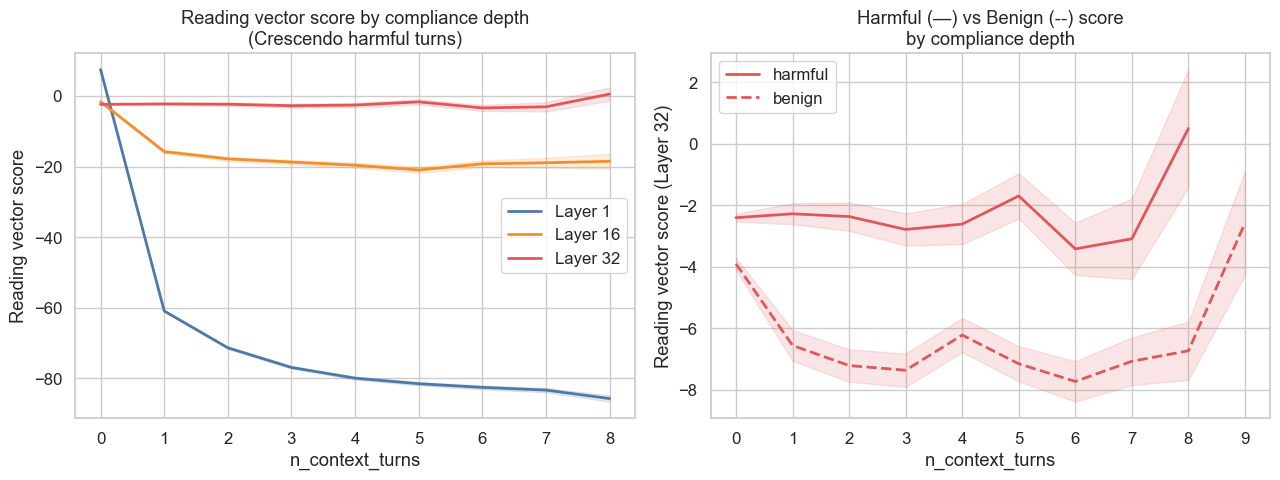

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

LAYER_COLORS = ["#4e79a7", "#f28e2b", "#e15759"]

# Left: mean reading vector score by n_context_turns (harmful turns)
ax = axes[0]
for li, (lname, color) in enumerate(zip(LAYER_NAMES, LAYER_COLORS)):
    sc, vec = reading_vectors[li]
    X_harm = get_layer(states_harm, li)
    scores = sc.transform(X_harm) @ vec
    meta_harm["rv_score"] = scores
    traj = meta_harm.groupby("n_context_turns")["rv_score"].agg(["mean", "sem", "count"])
    traj = traj[traj["count"] >= 5]
    ax.plot(traj.index, traj["mean"], color=color, label=lname, linewidth=2)
    ax.fill_between(traj.index,
                    traj["mean"] - traj["sem"],
                    traj["mean"] + traj["sem"],
                    color=color, alpha=0.15)

ax.set_xlabel("n_context_turns")
ax.set_ylabel("Reading vector score")
ax.set_title("Reading vector score by compliance depth
(Crescendo harmful turns)")
ax.legend()
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# Right: harmful vs benign scores by n_context_turns (Layer 32)
ax = axes[1]
li = 2
sc, vec = reading_vectors[li]

for label_val, label_name, states_s, meta_s, ls in [
    (1, "harmful", states_harm, meta_harm, "-"),
    (0, "benign",  states_ben,  meta_ben,  "--"),
]:
    scores = sc.transform(get_layer(states_s, li)) @ vec
    meta_s = meta_s.copy()
    meta_s["rv_score"] = scores
    traj = meta_s.groupby("n_context_turns")["rv_score"].agg(["mean", "sem", "count"])
    traj = traj[traj["count"] >= 5]
    ax.plot(traj.index, traj["mean"], linestyle=ls,
            color="#e15759", label=label_name, linewidth=2)
    ax.fill_between(traj.index,
                    traj["mean"] - traj["sem"],
                    traj["mean"] + traj["sem"],
                    color="#e15759", alpha=0.15)

ax.set_xlabel("n_context_turns")
ax.set_ylabel("Reading vector score (Layer 32)")
ax.set_title("Harmful (—) vs Benign (--) score
by compliance depth")
ax.legend()
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig(FIG_DIR / "paired_rv_compliance_depth.png", dpi=150)
plt.show()

## Cross-framework transfer

Project ActorAttack and X-Teaming turns onto the Crescendo reading vector.
Does the vector score harmful > benign for those frameworks too?
Does the score track n_context_turns?

In [9]:
OTHER_DATASETS = {
    "actorattack": (
        "actorattack_harmful_faithful",
        "actorattack_benign_faithful",
    ),
    "xteaming": (
        "xteaming_harmful_faithful",
        "xteaming_benign_faithful",
    ),
}

li = 2  # Layer 32
sc, vec = reading_vectors[li]

print("Transfer: Crescendo reading vector → other frameworks (Layer 32)")
print(f"{'Framework':<20} {'Split':<10} {'Mean score':>12} {'AUC':>8}")
print("-" * 52)

# Crescendo baseline
for split_name, states_s, meta_s in [
    ("harmful", states_harm, meta_harm),
    ("benign",  states_ben,  meta_ben),
]:
    scores = sc.transform(get_layer(states_s, li)) @ vec
    print(f"{'crescendo':<20} {split_name:<10} {scores.mean():>12.4f}")

# AUC for crescendo
h_scores = sc.transform(get_layer(states_harm, li)) @ vec
b_scores = sc.transform(get_layer(states_ben,  li)) @ vec
y_cresc  = np.concatenate([np.ones(len(h_scores)), np.zeros(len(b_scores))])
all_scores_cresc = np.concatenate([h_scores, b_scores])
print(f"  crescendo AUC: {roc_auc_score(y_cresc, all_scores_cresc):.3f}")
print()

# Other frameworks
fw_colors_ext = {"actorattack": "#4e79a7", "xteaming": "#59a14f"}
transfer_results = {}

for fw, (harm_dir, ben_dir) in OTHER_DATASETS.items():
    try:
        sh, mh = load_repr(harm_dir)
        sb, mb = load_repr(ben_dir)
    except FileNotFoundError:
        print(f"{fw}: representations not found — run nb14 first")
        continue

    h_sc = sc.transform(get_layer(sh.astype(np.float32), li)) @ vec
    b_sc = sc.transform(get_layer(sb.astype(np.float32), li)) @ vec

    print(f"{fw:<20} {'harmful':<10} {h_sc.mean():>12.4f}")
    print(f"{fw:<20} {'benign':<10}  {b_sc.mean():>12.4f}")

    y_fw = np.concatenate([np.ones(len(h_sc)), np.zeros(len(b_sc))])
    auc  = roc_auc_score(y_fw, np.concatenate([h_sc, b_sc]))
    print(f"  {fw} AUC: {auc:.3f}")
    print()

    transfer_results[fw] = {"sh": sh, "mh": mh, "sb": sb, "mb": mb,
                             "h_sc": h_sc, "b_sc": b_sc}

Transfer: Crescendo reading vector → other frameworks (Layer 32)
Framework            Split        Mean score      AUC
----------------------------------------------------
crescendo            harmful         -2.4106
crescendo            benign          -5.6326
  crescendo AUC: 0.581

actorattack          harmful         -9.4385
actorattack          benign          -10.3867
  actorattack AUC: 0.529

xteaming             harmful          0.7805
xteaming             benign            1.1163
  xteaming AUC: 0.485



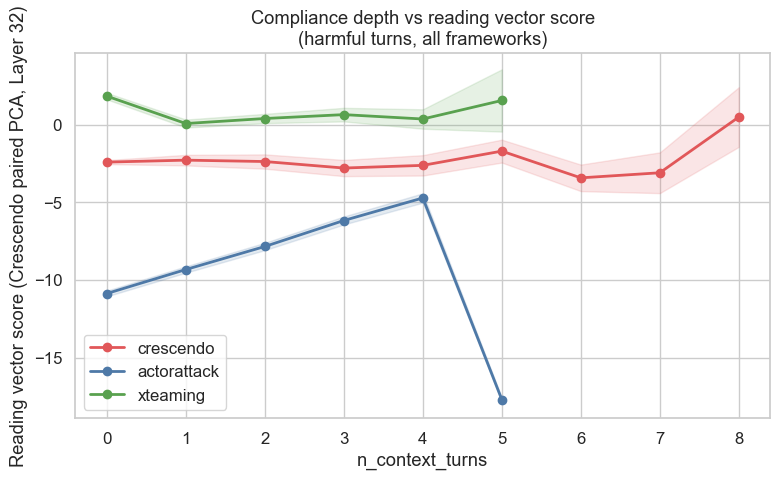

In [10]:
# Reading vector score vs n_context_turns per framework (harmful only)
fig, ax = plt.subplots(figsize=(8, 5))

# Crescendo
scores = sc.transform(get_layer(states_harm, li)) @ vec
mh = meta_harm.copy()
mh["rv_score"] = scores
traj = mh.groupby("n_context_turns")["rv_score"].agg(["mean", "sem", "count"])
traj = traj[traj["count"] >= 5]
ax.plot(traj.index, traj["mean"], color="#e15759", linewidth=2,
        marker="o", label="crescendo")
ax.fill_between(traj.index, traj["mean"] - traj["sem"],
                traj["mean"] + traj["sem"], color="#e15759", alpha=0.15)

# Other frameworks
for fw, color in fw_colors_ext.items():
    if fw not in transfer_results:
        continue
    res = transfer_results[fw]
    mh_fw = res["mh"].copy()
    mh_fw["rv_score"] = res["h_sc"]
    traj = mh_fw.groupby("n_context_turns")["rv_score"].agg(["mean", "sem", "count"])
    traj = traj[traj["count"] >= 5]
    ax.plot(traj.index, traj["mean"], color=color, linewidth=2,
            marker="o", label=fw)
    ax.fill_between(traj.index, traj["mean"] - traj["sem"],
                    traj["mean"] + traj["sem"], color=color, alpha=0.15)

ax.set_xlabel("n_context_turns")
ax.set_ylabel("Reading vector score (Crescendo paired PCA, Layer 32)")
ax.set_title("Compliance depth vs reading vector score
(harmful turns, all frameworks)")
ax.legend()
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.tight_layout()
plt.savefig(FIG_DIR / "paired_rv_transfer_depth.png", dpi=150)
plt.show()

## Summary

In [11]:
print("=" * 60)
print("PAIRED CONTRAST READING VECTOR — SUMMARY")
print("=" * 60)
print(f"
Matched pairs used for training: {len(merged)}")
print(f"Unique objectives: {merged['pair_id'].nunique()}")
print()
print("Within-pair concordance (harmful scored > benign):")
for li in range(len(LAYER_INDICES)):
    sc_rv, vec_rv = reading_vectors[li]
    h = sc_rv.transform(get_layer(states_harm, li)[merged["idx_harm"].values]) @ vec_rv
    b = sc_rv.transform(get_layer(states_ben,  li)[merged["idx_ben"].values])  @ vec_rv
    print(f"  {LAYER_NAMES[li]}: {(h > b).mean():.3f}")
print()
print("Interpretation:")
print("  > 0.5 : reading vector scores harmful turns higher than matched benign turns")
print("  ~ 0.5 : reading vector has no within-pair discriminative power (topic only)")
print("  High concordance + increasing score with n_context_turns")
print("  => reading vector captures compliance priming, not just topic.")

PAIRED CONTRAST READING VECTOR — SUMMARY

Matched pairs used for training: 5670
Unique objectives: 93

Within-pair concordance (harmful scored > benign):
  Layer 1: 0.675
  Layer 16: 0.536
  Layer 32: 0.605

Interpretation:
  > 0.5 : reading vector scores harmful turns higher than matched benign turns
  ~ 0.5 : reading vector has no within-pair discriminative power (topic only)
  High concordance + increasing score with n_context_turns
  => reading vector captures compliance priming, not just topic.


---
## Compliance priming reading vector

The paired harm/benign reading vector above extracts a **harm-content direction**
(harmful topic vs. benign topic, same turn). But most pairs are at `n_context_turns=0`,
so PCA never sees the compliance priming shift.

To isolate the **compliance priming direction** specifically:

```
For each (pair_id, attempt) in Crescendo harmful:
    low  = hidden state at n_context_turns = 0
    high = hidden state at n_context_turns >= 3  (same conversation)
    diff = high - low
```

Same topic, same objective, same conversation — only compliance depth varies.
PCA on these diffs → first PC = compliance priming direction.

**Key evaluations:**
- Does the direction score increase monotonically with `n_context_turns`?
- Does it predict refusal (lower score → more likely to refuse)?
- Does it transfer to ActorAttack and X-Teaming?

In [13]:
HIGH_K_THRESHOLD = 3  # n_context_turns >= this is "deeply primed"

# Build within-conversation contrast pairs
low_idx, high_idx, pair_info = [], [], []

for (pid, att), grp in meta_harm.groupby(["pair_id", "attempt"]):
    low_rows  = grp[grp["n_context_turns"] == 0]
    high_rows = grp[grp["n_context_turns"] >= HIGH_K_THRESHOLD]
    if len(low_rows) == 0 or len(high_rows) == 0:
        continue
    # One pair per conversation: k=0 turn vs highest-k turn
    low_idx.append(low_rows.index[0])
    high_idx.append(high_rows.loc[high_rows["n_context_turns"].idxmax()].name)
    pair_info.append({
        "pair_id": pid,
        "attempt": att,
        "low_k":  meta_harm.loc[low_rows.index[0],  "n_context_turns"],
        "high_k": meta_harm.loc[high_rows.loc[high_rows["n_context_turns"].idxmax()].name,
                                  "n_context_turns"],
    })

pair_df = pd.DataFrame(pair_info)
print(f"Compliance contrast pairs: {len(pair_df)}")
print(f"Unique pair_ids:            {pair_df['pair_id'].nunique()}")
print(f"Unique attempts:            {pair_df.groupby(['pair_id','attempt']).ngroups}")
print(f"\
high_k distribution:")
print(pair_df["high_k"].value_counts().sort_index())

Compliance contrast pairs: 305
Unique pair_ids:            63
Unique attempts:            305
high_k distribution:
high_k
3    66
4    69
5    43
6    58
7    48
8    19
9     2
Name: count, dtype: int64


In [14]:
# Train compliance priming reading vector via PCA on (high_k - low_k) diffs
compliance_vectors = {}   # layer_pos -> (scaler, direction)

for li in range(len(LAYER_INDICES)):
    low_reps  = get_layer(states_harm, li)[low_idx]
    high_reps = get_layer(states_harm, li)[high_idx]
    D = high_reps - low_reps   # (N_pairs, 4096): what changes as k increases

    sc  = StandardScaler()
    D_sc = sc.fit_transform(D)

    pca = PCA(n_components=1, random_state=42)
    pca.fit(D_sc)
    vec = pca.components_[0]

    # Sign: high_k projections should be > low_k projections
    h_proj = sc.transform(high_reps) @ vec
    l_proj = sc.transform(low_reps)  @ vec
    if h_proj.mean() < l_proj.mean():
        vec = -vec

    compliance_vectors[li] = (sc, vec)
    print(f"Layer {LAYER_INDICES[li]}: explained_var={pca.explained_variance_ratio_[0]:.3%}  "
          f"low_k score={l_proj.mean():.4f}  high_k score={h_proj.mean():.4f}  "
          f"N={len(pair_df)}")

Layer 1: explained_var=15.373%  low_k score=33.8192  high_k score=3.0780  N=305
Layer 16: explained_var=8.459%  low_k score=25.9929  high_k score=10.8386  N=305
Layer 32: explained_var=6.053%  low_k score=-3.3069  high_k score=-2.7011  N=305


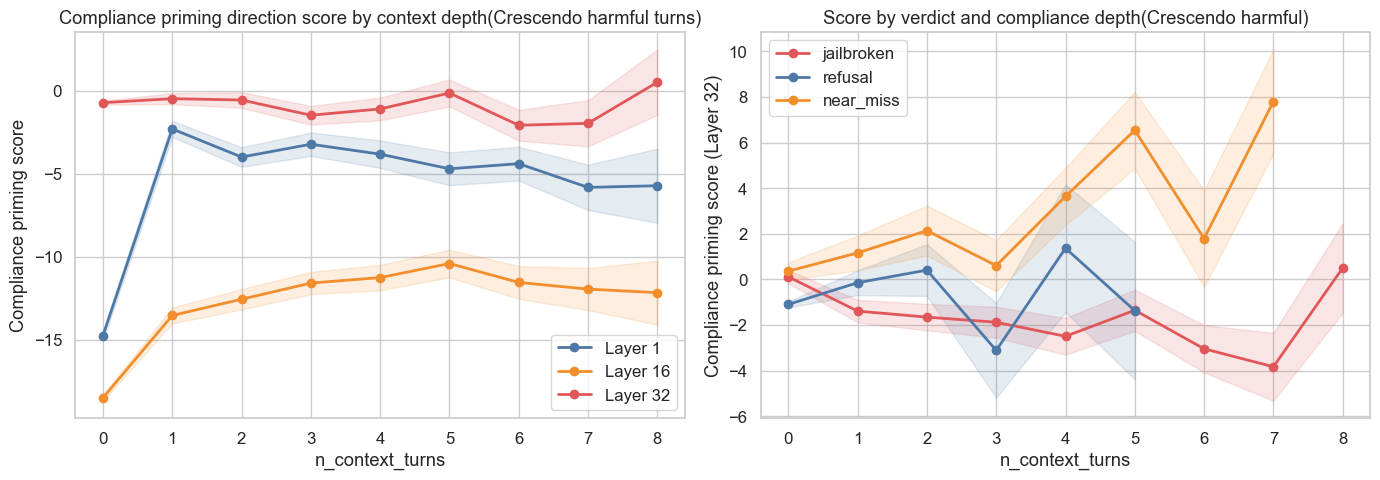

Layer 1: Spearman r=0.234  p=1.71e-114
Layer 16: Spearman r=0.191  p=1.43e-76
Layer 32: Spearman r=0.011  p=2.71e-01


In [15]:
# Does compliance priming score increase monotonically with n_context_turns?
# Project ALL harmful turns onto the compliance direction

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: score by n_context_turns, all layers
ax = axes[0]
for li, (lname, color) in enumerate(zip(LAYER_NAMES, LAYER_COLORS)):
    sc_cv, vec_cv = compliance_vectors[li]
    scores = sc_cv.transform(get_layer(states_harm, li)) @ vec_cv
    meta_harm["cp_score"] = scores
    traj = meta_harm.groupby("n_context_turns")["cp_score"].agg(["mean", "sem", "count"])
    traj = traj[traj["count"] >= 5]
    ax.plot(traj.index, traj["mean"], color=color, label=lname, linewidth=2, marker="o")
    ax.fill_between(traj.index,
                    traj["mean"] - traj["sem"],
                    traj["mean"] + traj["sem"], color=color, alpha=0.15)

ax.set_xlabel("n_context_turns")
ax.set_ylabel("Compliance priming score")
ax.set_title("Compliance priming direction score by context depth\
(Crescendo harmful turns)")
ax.legend()
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# Right: score by n_context_turns, Layer 32, split by final_verdict
ax = axes[1]
li = 2
sc_cv, vec_cv = compliance_vectors[li]
scores = sc_cv.transform(get_layer(states_harm, li)) @ vec_cv
meta_harm["cp_score"] = scores

verdict_colors = {"jailbroken": "#e15759", "refusal": "#4e79a7", "near_miss": "#f28e2b"}
for verdict, color in verdict_colors.items():
    mask = meta_harm["final_verdict"] == verdict
    if mask.sum() < 10:
        continue
    traj = meta_harm[mask].groupby("n_context_turns")["cp_score"].agg(["mean", "sem", "count"])
    traj = traj[traj["count"] >= 5]
    ax.plot(traj.index, traj["mean"], color=color, label=verdict, linewidth=2, marker="o")
    ax.fill_between(traj.index,
                    traj["mean"] - traj["sem"],
                    traj["mean"] + traj["sem"], color=color, alpha=0.15)

ax.set_xlabel("n_context_turns")
ax.set_ylabel("Compliance priming score (Layer 32)")
ax.set_title("Score by verdict and compliance depth\
(Crescendo harmful)")
ax.legend()
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig(FIG_DIR / "compliance_rv_depth.png", dpi=150)
plt.show()

# Spearman correlation: score vs n_context_turns
from scipy.stats import spearmanr
for li, lname in enumerate(LAYER_NAMES):
    sc_cv, vec_cv = compliance_vectors[li]
    scores = sc_cv.transform(get_layer(states_harm, li)) @ vec_cv
    r, p = spearmanr(meta_harm["n_context_turns"], scores)
    print(f"{lname}: Spearman r={r:.3f}  p={p:.2e}")

crescendo: Spearman r=0.011  p=2.71e-01
actorattack: Spearman r=-0.126  p=1.99e-26
xteaming: Spearman r=-0.070  p=9.44e-05
crescendo: outcome AUC (jailbroken vs refusal) = 0.509
actorattack: outcome AUC (jailbroken vs refusal) = 0.434
xteaming: outcome AUC (jailbroken vs refusal) = 0.474


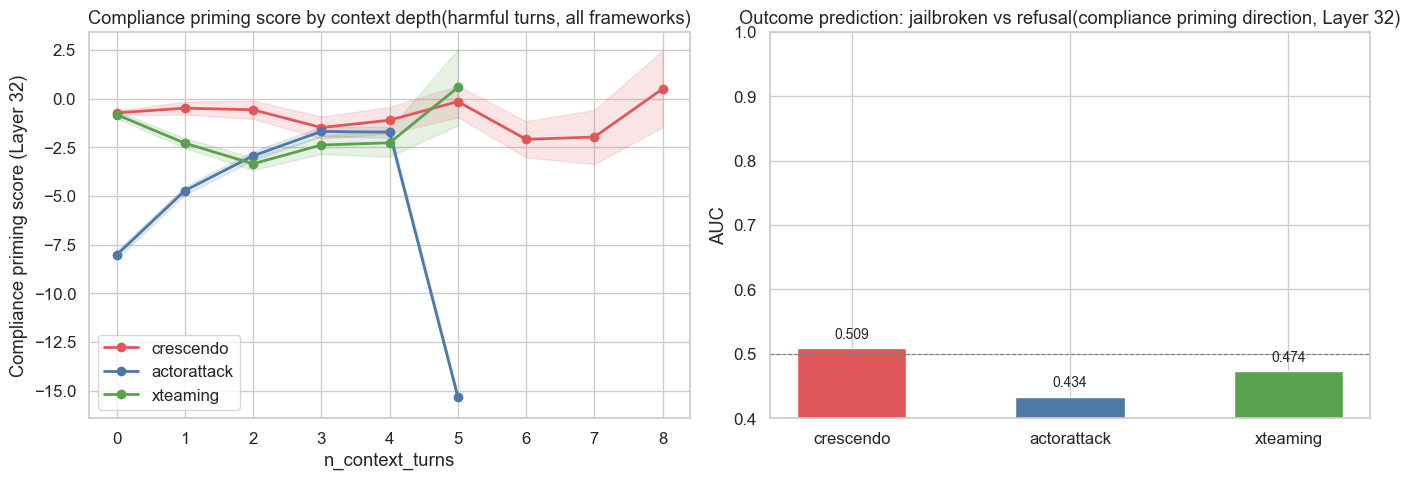

In [16]:
# Cross-framework transfer of the compliance priming direction
# Does the score track n_context_turns for ActorAttack and X-Teaming?

li = 2  # Layer 32
sc_cv, vec_cv = compliance_vectors[li]

fw_colors_all = {
    "crescendo":   "#e15759",
    "actorattack": "#4e79a7",
    "xteaming":    "#59a14f",
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: score vs n_context_turns per framework (harmful only)
ax = axes[0]
for fw, color in fw_colors_all.items():
    if fw == "crescendo":
        states_fw, meta_fw = states_harm, meta_harm
    else:
        try:
            harm_dir = f"{fw}_harmful_faithful"
            states_fw, meta_fw = load_repr(harm_dir)
            states_fw = states_fw.astype(np.float32)
        except FileNotFoundError:
            print(f"{fw}: missing — run nb14 first")
            continue

    scores = sc_cv.transform(get_layer(states_fw, li)) @ vec_cv
    meta_fw = meta_fw.copy()
    meta_fw["cp_score"] = scores
    traj = meta_fw.groupby("n_context_turns")["cp_score"].agg(["mean", "sem", "count"])
    traj = traj[traj["count"] >= 5]
    ax.plot(traj.index, traj["mean"], color=color, linewidth=2,
            marker="o", label=fw)
    ax.fill_between(traj.index,
                    traj["mean"] - traj["sem"],
                    traj["mean"] + traj["sem"], color=color, alpha=0.15)

    r, p = spearmanr(meta_fw["n_context_turns"], scores)
    print(f"{fw}: Spearman r={r:.3f}  p={p:.2e}")

ax.set_xlabel("n_context_turns")
ax.set_ylabel("Compliance priming score (Layer 32)")
ax.set_title("Compliance priming score by context depth\
(harmful turns, all frameworks)")
ax.legend()
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# Right: refusal prediction — does compliance score predict verdict?
# AUC: jailbroken vs refusal, score as predictor
ax = axes[1]
results = []
for fw, color in fw_colors_all.items():
    if fw == "crescendo":
        states_fw, meta_fw = states_harm, meta_harm
    else:
        try:
            states_fw, meta_fw = load_repr(f"{fw}_harmful_faithful")
            states_fw = states_fw.astype(np.float32)
        except FileNotFoundError:
            continue

    scores = sc_cv.transform(get_layer(states_fw, li)) @ vec_cv
    meta_fw = meta_fw.copy()
    meta_fw["cp_score"] = scores

    mask = meta_fw["final_verdict"].isin(["jailbroken", "refusal"])
    if mask.sum() < 20:
        continue
    y = (meta_fw[mask]["final_verdict"] == "jailbroken").astype(int).values
    s = scores[mask.values]
    if len(np.unique(y)) < 2:
        continue
    auc = roc_auc_score(y, s)
    results.append({"framework": fw, "auc": auc, "color": color})
    print(f"{fw}: outcome AUC (jailbroken vs refusal) = {auc:.3f}")

if results:
    df_r = pd.DataFrame(results)
    bars = ax.bar(df_r["framework"], df_r["auc"],
                  color=df_r["color"], width=0.5, edgecolor="white")
    ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8)
    ax.set_ylim(0.4, 1.0)
    ax.set_ylabel("AUC")
    ax.set_title("Outcome prediction: jailbroken vs refusal\
(compliance priming direction, Layer 32)")
    for bar, row in zip(bars, results):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{row['auc']:.3f}", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.savefig(FIG_DIR / "compliance_rv_transfer.png", dpi=150)
plt.show()